### [ Fish 데이터 다중 클래스 분류: 희소 클래스 기타(Other) 처리 ]

- **학습 목표**
    - 데이터 : fish.csv
        * 7종의 생선 품종
        * Whitefish는 데이터가 6개뿐
        * class_weight="balanced"만으로는 안정적인 성능을 얻기 어려움

    - 보완 학습
        1. 원본 데이터의 클래스 불균형 확인
        2. class_weight의 한계
        3. 데이터가 적은 품종을 Other(기타) 범주로 통합
        4. DecisionTreeClassifier로 교차검증 수행
        5. GridSearchCV로 하이퍼파라미터 튜닝
        6. 최종 모델 학습 및 테스트 데이터 평가

- **핵심 정리**
    - class_weight의 한계
        * class_weight="balanced" : 소수 클래스에 더 큰 가중치 부여
        * 데이터 자체를 늘려주는 방법은 아님.
        * 즉, Whitefish가 6개뿐이면 모델이 볼 수 있는 Whitefish의 형태가 너무 적음

    - 업샘플링 / SMOTE의 한계
        * 업샘플링은 적은 데이터를 복사하고, SMOTE는 가상의 데이터를 만듦
        * 원본 데이터가 너무 적으면 복사하거나 가상 데이터를 만들어도 실제 다양성이 충분하지 않음
        
    - 기타 범주 통합
        * 싷무에서는 데이터가 너무 적은 클래스는 하나의 범주로 묶는 경우가 많음
        * Whitefish, Parkki, Smelt처럼 데이터 개수가 적은 품종 ==> Other로 묶음
        * 모델이 더 안정적으로 학습할 수 있음

- **[0]모듈 로딩**

In [ ]:
## 데이터 처리를 위한 라이브러리
import pandas as pd
import numpy as np

## 시각화를 위한 라이브러리
import matplotlib.pyplot as plt
import koreanize_matplotlib

## 데이터 분리
from sklearn.model_selection import train_test_split

## ML 전처리 관련
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder

## ML 교차검증 및 하이퍼파라미터 튜닝
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV

## ML 모델
from sklearn.tree import DecisionTreeClassifier

## ML 평가 지표
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay




```
# 코드로 형식 지정됨
```

- **[1]데이터 준비**

In [ ]:
## 데이터 준비
DATA_FILE = '../Data/Numbers/fish.csv'

## 데이터 로딩 => 첫번째 줄 컬럼명, 데이터 구분 쉼표(,)
fishDF = pd.read_csv(DATA_FILE)


In [ ]:
## 데이터 기본 정보 확인
fishDF.info()
fishDF.head(2)

## 클래스 개수 및 비율
print('클래스별 이름       : ', fishDF['Species'].value_counts().index )
print('클래스별 데이터 개수 : ', fishDF['Species'].value_counts().to_list())
print('클래스별 데이터 비율 : ', fishDF['Species'].value_counts(normalize=True).round(1).tolist())

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    str    
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), str(1)
memory usage: 7.6 KB
클래스별 이름       :  Index(['Perch', 'Bream', 'Roach', 'Pike', 'Smelt', 'Parkki', 'Whitefish'], dtype='str', name='Species')
클래스별 데이터 개수 :  [56, 35, 20, 17, 14, 11, 6]
클래스별 데이터 비율 :  [0.4, 0.2, 0.1, 0.1, 0.1, 0.1, 0.0]


In [ ]:
## 컬럼별 데이터 분포
fishDF.describe(include = 'all')

## -----------------------------------------------------------
## => 해석
## - Weight  컬럼 : 최소값 0 ---> 몇 개 존재. 이상치
## - Species 컬럼 : str     ---> category 형변환
##                 타겟 컬럼으로 LabelEncoding 진행
##                 고유값 7개 --> 다중 클래스 분류 | 불균형 데이터셋
## - 수치값 컬럼들 : 값 차이 크게 남 --> 스케일링 필요
## -----------------------------------------------------------

,Species,Weight,Length,Diagonal,Height,Width
count,159,159.000000,159.000000,159.000000,159.000000,159.000000
unique,7,NaN,NaN,NaN,NaN,NaN
top,Perch,NaN,NaN,NaN,NaN,NaN
freq,56,NaN,NaN,NaN,NaN,NaN
mean,NaN,398.326415,28.415723,31.227044,8.970994,4.417486
std,NaN,357.978317,10.716328,11.610246,4.286208,1.685804
min,NaN,0.000000,8.400000,8.800000,1.728400,1.047600
25%,NaN,120.000000,21.000000,23.150000,5.944800,3.385650
50%,NaN,273.000000,27.300000,29.400000,7.786000,4.248500
75%,NaN,650.000000,35.500000,39.650000,12.365900,5.584500


- **[2]원본 클래스 분포 확인**

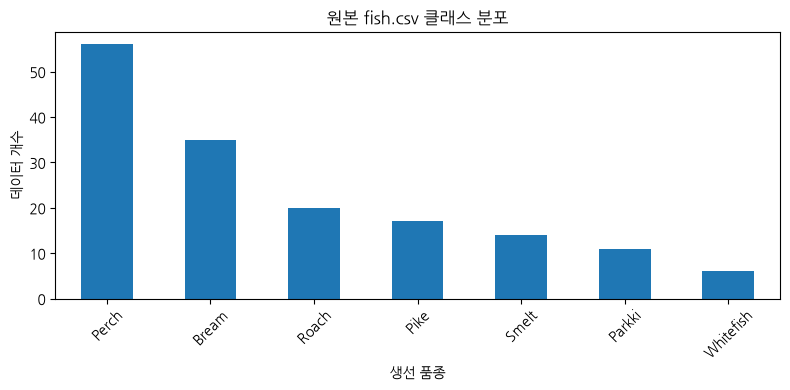

In [ ]:
## 원본 Species 클래스별 개수 확인
original_counts = fishDF['Species'].value_counts()

## 클래스 분포 시각화
plt.figure(figsize=(8, 4))
original_counts.plot(kind='bar')
plt.title('원본 fish.csv 클래스 분포')
plt.xlabel('생선 품종')
plt.ylabel('데이터 개수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
## [학습 설계] -------------------------------------------------------------------------------
## - Whitefish 문제!!! 데이터가 6개.
## - 5-Fold 교차검증을 하면 각 검증 fold에는 Whitefish가 1개 정도만 들어갈 수 있음
## - 이 경우 모델이 Whitefish를 잘 학습하기 어렵고, 평가 결과도 fold에 따라 크게 흔들릴 수 있음
##
## - 데이터 개수가 일정 기준 이하인 클래스들 => Other로 통합
## - 기준 : 15개 이하로 설정
## - 품종 : Other
##   * Whitefish: 6개
##   * Parkki: 11개
##   * Smelt: 14개
##   * => Other 클래스 : 총 31개 => 교차검증이 더 안정적
## --------------------------------------------------------------------------------------

- **[3]데이터 가공**

In [ ]:
## 기준값 설정
## -> 데이터 개수가 15개 이하인 품종은 Other로 묶음
rare_threshold = 15

## Species별 데이터 개수 계산
species_counts = fishDF['Species'].value_counts()

## rare_threshold 이하인 클래스 이름 추출
rare_classes = species_counts[species_counts <= rare_threshold].index

## 어떤 클래스가 Other로 묶이는지 확인
print(f'Other로 묶을 클래스: {list(rare_classes)}' )

Other로 묶을 클래스: ['Smelt', 'Parkki', 'Whitefish']


In [ ]:
## 원본 데이터 복사
fish_df = fishDF.copy()

## Species_new 컬럼 생성
## rare_classes에 해당하면 Other, 아니면 원래 품종명 유지
fish_df['Species_new'] = fish_df['Species'].apply( lambda x: 'Other' if x in rare_classes else x)

## 변경 전/후 확인
print(fish_df['Species_new'].unique().tolist())

['Bream', 'Roach', 'Other', 'Perch', 'Pike']


In [ ]:
## 클래스 개수 및 비율
print('클래스별 이름       : ', fish_df['Species_new'].value_counts().index )
print('클래스별 데이터 개수 : ', fish_df['Species_new'].value_counts().to_list())
print('클래스별 데이터 비율 : ', fish_df['Species_new'].value_counts(normalize=True).round(1).tolist())

클래스별 이름       :  Index(['Perch', 'Bream', 'Other', 'Roach', 'Pike'], dtype='str', name='Species_new')
클래스별 데이터 개수 :  [56, 35, 31, 20, 17]
클래스별 데이터 비율 :  [0.4, 0.2, 0.2, 0.1, 0.1]


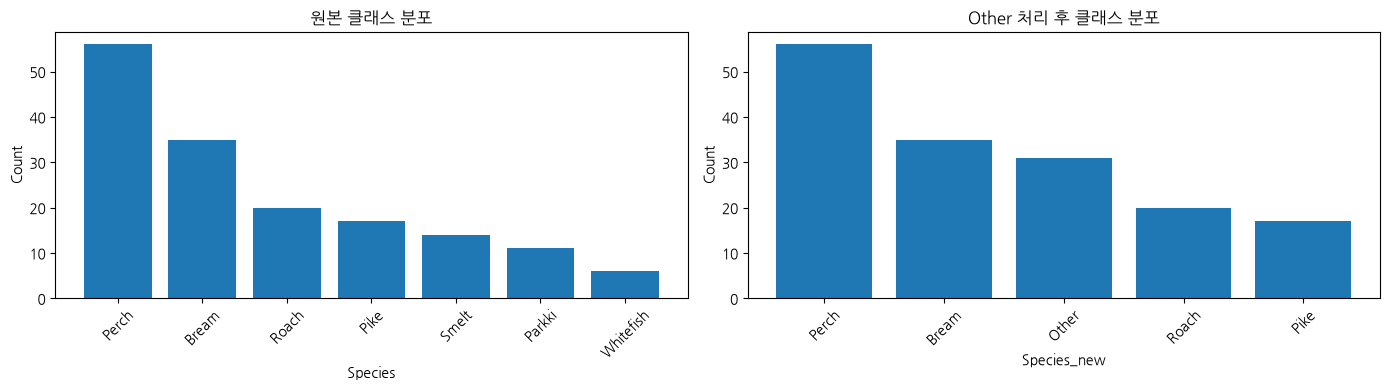

In [ ]:
## 원본 클래스 분포와 Other 처리 후 클래스 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

titles  = ['원본 클래스 분포', 'Other 처리 후 클래스 분포']
xlabels = ['Species', 'Species_new']
for ax, title, xlabel in zip(axes, titles, xlabels):
    dataSR = fish_df[xlabel].value_counts()
    ax.bar(dataSR.index, dataSR.values)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- **[4] 피쳐와 타겟 분리**
    * 타겟 : Species_new
    * 피쳐 : Weight, Length, Diagonal, Height, Width

In [ ]:
## 피쳐와 타겟 분리
featureDF = fish_df[fish_df.columns[1:-1]]
targetSR  = fish_df[fish_df.columns[-1]]

print(f'피쳐 : {featureDF.shape}, {featureDF.columns}')
print(f'타겟 : {targetSR.shape},  {targetSR.unique().tolist()}')

피쳐 : (159, 5), Index(['Weight', 'Length', 'Diagonal', 'Height', 'Width'], dtype='str')
타겟 : (159,),  ['Bream', 'Roach', 'Other', 'Perch', 'Pike']


- **[5] 학습 데이터와 테스트 데이터 분리**

In [ ]:
## 분류 문제 : stratify 사용해서 클래스 비율 유지 분리
## 재  현 성 : random_stae 설정
X_train, X_test, y_train, y_test = train_test_split(featureDF,
                                                    targetSR,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=targetSR )

In [ ]:
print(f'[TRAIN]\n{X_train.shape}, {y_train.shape}')
print(f'클래스 개수: {y_train.value_counts().to_list()}\n')

print(f'[TEST]\n{X_test.shape}, {y_test.shape}')
print(f'클래스 개수: {y_test.value_counts().to_list()}\n')

[TRAIN]
(127, 5), (127,)
클래스 개수: [45, 28, 25, 16, 13]

[TEST]
(32, 5), (32,)
클래스 개수: [11, 7, 6, 4, 4]



- **[6] 타겟 인코딩**

In [ ]:
## ------------------------------------------
## 타겟 컬럼 인코딩 => Pipeline은 피쳐 처리
## ------------------------------------------
## 인코더 인스턴스 생성
lbEncoder  = LabelEncoder()

## 학습용 데이터셋 기반 인코딩 기준 설정 및 변환
y_train_en = lbEncoder.fit_transform(y_train)

## 학습용 데이터셋 기준으로 테스트 데이터셋 변환
y_test_en  = lbEncoder.transform(y_test)

## 인코더 정보 확인 : fit()통해서 저장된 정보
print(f'classes_ : {lbEncoder.classes_ }')

classes_ : ['Bream' 'Other' 'Perch' 'Pike' 'Roach']


- **[7] DT모델 + 교차검증**
    - 모__델 : DecisionTreeClassifier
    - 데이터
        * 모델 설정: class_weight='balanced'
        * 평가지표
            - accuracy: 전체 정답률
            - precision_macro: 클래스별 정밀도의 평균
            - recall_macro: 클래스별 재현율의 평균
            - f1_macro: 클래스별 F1 점수의 평균

In [ ]:
## 모델 인스턴스 생성
## - class_weight='balanced'
## - 클래스 개수에 반비례하여 가중치를 자동으로 부여
dt_model = DecisionTreeClassifier( random_state=42, class_weight='balanced' )

## 분류형 교차검증 인스턴스 StratifiedKFold 생성
## - 각 fold에 클래스 비율이 비슷하게 들어가도록 함
skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=42 )

## 교차검증에서 사용할 평가 지표 설정
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

## 교차검증 수행
cv_result = cross_validate(
    dt_model,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring,
    return_train_score=True,
    n_jobs=1
)



In [ ]:
## 결과 확인
resultDF = pd.DataFrame(cv_result)

print('기본 DecisionTree 교차검증 결과')
print('-' * 40)
print('Train Accuracy       평균 :', resultDF['train_accuracy'].mean())
print('Test Accuracy        평균 :', resultDF['test_accuracy'].mean())
print('Test Precision_macro 평균 :', resultDF['test_precision_macro'].mean())
print('Test Recall_macro    평균 :', resultDF['test_recall_macro'].mean())
print('Test F1_macro        평균 :', resultDF['test_f1_macro'].mean())

기본 DecisionTree 교차검증 결과
----------------------------------------
Train Accuracy       평균 : 1.0
Test Accuracy        평균 : 0.668923076923077
Test Precision_macro 평균 : 0.7003650793650793
Test Recall_macro    평균 : 0.6624444444444444
Test F1_macro        평균 : 0.6582827695180636


- **[8] 파이프라인 + 교차검증 + 튜닝 준비**
    - DecisionTree는 과대적합이 잘 발생하는 모델
    - 파라미터를 조정
        - max_depth: 트리의 최대 깊이
        - min_samples_split: 노드를 나누기 위한 최소 샘플 수
        - min_samples_leaf: 리프 노드에 필요한 최소 샘플 수
        - criterion: 분할 기준
    - 불균형 다중 클래스 문제 : f1_macro 기준으로 최적 모델을 선택

In [ ]:
## 기본 모델 생성
base_dt = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

## 탐색할 하이퍼파라미터 후보
params = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [3, 4, 5, 6, 7, None],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 3, 4]
}

## 분류형 교차검증 인스턴스 StratifiedKFold 생성
## - 각 fold에 클래스 비율이 비슷하게 들어가도록 함
skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=42 )

## 교차검증에서 사용할 평가 지표 설정
scoring = ['accuracy', 'f1_macro']

## GridSearchCV 생성
## refit='f1_macro'이므로 f1_macro가 가장 좋은 모델을 최종 모델로 다시 학습
grid_dt = GridSearchCV(
    estimator=base_dt,
    param_grid=params,
    scoring=scoring,
    refit='f1_macro',
    cv=skf,
    n_jobs=1,
    return_train_score=True
)


In [ ]:
## GridSearchCV 학습
grid_dt.fit(X_train, y_train)

print('최적 파라미터:', grid_dt.best_params_)
print('최고 f1_macro:', grid_dt.best_score_)

최적 파라미터: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 3, 'min_samples_split': 2}
최고 f1_macro: 0.6890653148021568


In [ ]:
## GridSearchCV 결과를 DataFrame으로 변환
grid_result_df = pd.DataFrame(grid_dt.cv_results_)

## 필요한 컬럼만 선택해서 성능이 좋은 순서대로 확인
result_cols = [
    'mean_train_f1_macro',
    'mean_test_f1_macro',
    'mean_test_accuracy',
    'param_criterion',
    'param_max_depth',
    'param_min_samples_split',
    'param_min_samples_leaf'
]

grid_result_df[result_cols].sort_values(
    by='mean_test_f1_macro',
    ascending=False
).head(10)

,mean_train_f1_macro,mean_test_f1_macro,mean_test_accuracy,param_criterion,param_max_depth,param_min_samples_split,param_min_samples_leaf
266,0.878519,0.689065,0.692615,log_loss,7,6,3
265,0.878519,0.689065,0.692615,log_loss,7,4,3
264,0.878519,0.689065,0.692615,log_loss,7,2,3
169,0.878519,0.689065,0.692615,entropy,7,4,3
170,0.878519,0.689065,0.692615,entropy,7,6,3
168,0.878519,0.689065,0.692615,entropy,7,2,3
185,0.891359,0.688056,0.692308,entropy,None,4,3
280,0.891359,0.688056,0.692308,log_loss,None,2,3
281,0.891359,0.688056,0.692308,log_loss,None,4,3
186,0.891359,0.688056,0.692308,entropy,None,6,3


- **[9] 평가**

In [ ]:
## GridSearchCV가 찾은 최적 모델
best_model = grid_dt.best_estimator_

## 테스트 데이터 예측
y_pred = best_model.predict(X_test)

## 정확도 출력
print('테스트 정확도:', accuracy_score(y_test, y_pred))

## classification_report 출력
print('분류 리포트')
print(classification_report(y_test, y_pred, zero_division=0))

테스트 정확도: 0.8125
분류 리포트
              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00         7
       Other       0.83      0.83      0.83         6
       Perch       0.80      0.73      0.76        11
        Pike       0.67      1.00      0.80         4
       Roach       0.67      0.50      0.57         4

    accuracy                           0.81        32
   macro avg       0.79      0.81      0.79        32
weighted avg       0.82      0.81      0.81        32



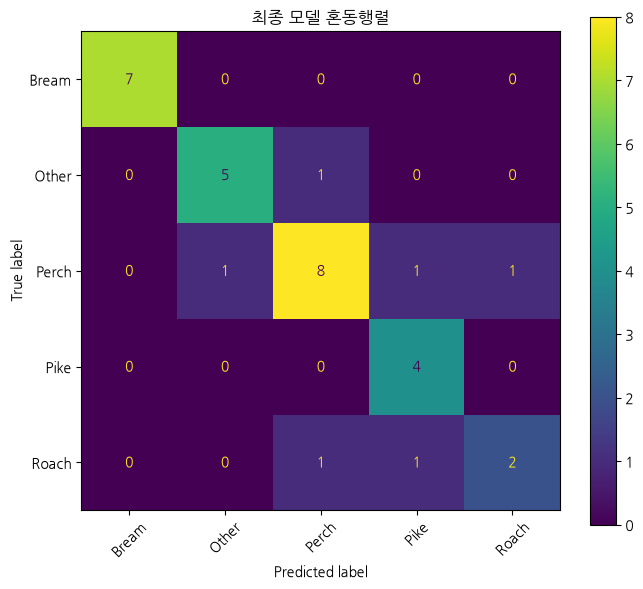

In [ ]:
## 혼동행렬 생성
labels = best_model.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)

# 혼동행렬 시각화
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format='d')
plt.title('최종 모델 혼동행렬')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()